### **Predicting Recommendation Probability Using Regression Model on User Interaction on E-commerce Products**

### Defining the Business Problem

Our objective is to demonstrate the end-to-end application of the machine learning lifecycle—including problem framing, data preprocessing, modelling, evaluation and result communication—on a real-world, industry-relevant dataset of choice.

The goal of this project is to develop a content-based recommendation model for an e-commerce platform that accurately predicts the probability of a product being recommended to another customer, thereby enhancing personalization and optimizing product discovery. The goal is to provide highly relevant product suggestions that are likely to resonate with individual user preferences, ultimately increasing user engagement, conversion rates, and overall customer satisfaction.

### Exploratory Data Analysis

First, we import and analyze the selected ecommerce data from Kagglehub.

In [21]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("kartikeybartwal/ecomerce-product-recommendation-dataset")

print("Path to dataset files:", path)

# List files in the downloaded directory
files = os.listdir(path)
print("Files in dataset directory:", files)

# Assuming there's a CSV file, find and load it
csv_files = [f for f in files if f.endswith('.csv')]

if csv_files:
    # Taking the first CSV file found
    data_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file_path)
    print("\nDataFrame head:")
    display(df.head())

    print("\nDataFrame Info:")
    df.info()

    print("\nDataFrame Description (Numerical Columns):")
    display(df.describe())

else:
    print("No CSV files found in the dataset directory.")

Using Colab cache for faster access to the 'ecomerce-product-recommendation-dataset' dataset.
Path to dataset files: /kaggle/input/ecomerce-product-recommendation-dataset
Files in dataset directory: ['content_based_recommendation_dataset.csv']

DataFrame head:


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Gender,Median purchasing price (in rupees),Rating of the product,Brand of the product,Customer review sentiment score (overall),Price of the product,Holiday,Season,Geographical locations,Probability for the product to be recommended to the person
0,12,4,4.2,male,500,4.5,PUMA,0.8,200,No,winter,plains,0.9
1,8,2,3.8,female,3000,3.2,Lee,-0.4,300,Yes,monsoon,mountains,0.2
2,25,10,4.5,female,600,4.8,Head Hunters,0.6,1000,No,spring,plains,0.7
3,6,1,2.1,female,100,2.5,Johnson & Johnson,0.1,300,No,summer,coastal,0.1
4,18,5,4.7,male,2000,4.3,Wakefit,0.9,700,Yes,winter,plains,0.8



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 13 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Number of clicks on similar products                         1474 non-null   int64  
 1   Number of similar products purchased so far                  1474 non-null   int64  
 2   Average rating given to similar products                     1474 non-null   float64
 3   Gender                                                       1474 non-null   object 
 4   Median purchasing price (in rupees)                          1474 non-null   int64  
 5   Rating of the product                                        1474 non-null   float64
 6   Brand of the product                                         1474 non-null   object 
 7   Customer review sentiment score (overall)                    

,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Median purchasing price (in rupees),Rating of the product,Customer review sentiment score (overall),Price of the product,Probability for the product to be recommended to the person
count,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000
mean,20.846676,9.225237,3.970963,2720.284939,4.059430,0.473474,1142.910448,0.674562
std,11.315669,5.356612,0.832315,3045.898434,0.829928,0.503922,1961.069130,0.317863
min,0.000000,0.000000,0.000000,100.000000,0.000000,-1.000000,90.000000,0.000000
25%,11.000000,5.000000,3.400000,500.000000,3.500000,0.100000,400.000000,0.450000
50%,19.000000,9.000000,4.200000,1000.000000,4.300000,0.700000,600.000000,0.800000
75%,28.750000,13.000000,4.700000,5000.000000,4.800000,0.900000,900.000000,0.900000
max,55.000000,24.000000,5.000000,19000.000000,5.000000,1.000000,10000.000000,1.000000


Next, we clean the data via handling null entries or duplicates.

In [22]:
print("\n--- Checking for Missing Values ---")
missing_values = df.isnull().sum()
print("Number of missing values per column:\n", missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the DataFrame.")
else:
    print(f"Total missing values in the DataFrame: {missing_values.sum()}")

print("\n--- Checking for Duplicate Entries ---")
duplicate_rows = df.duplicated().sum()
if duplicate_rows == 0:
    print("No duplicate rows found in the DataFrame.")
else:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    print("Displaying the first 10 duplicate rows (duplicates across all columns):")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))


--- Checking for Missing Values ---
Number of missing values per column:
 Series([], dtype: int64)
No missing values found in the DataFrame.

--- Checking for Duplicate Entries ---
Number of duplicate rows found: 456
Displaying the first 10 duplicate rows (duplicates across all columns):


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Gender,Median purchasing price (in rupees),Rating of the product,Brand of the product,Customer review sentiment score (overall),Price of the product,Holiday,Season,Geographical locations,Probability for the product to be recommended to the person
817,1,0,1.0,female,100,1.0,Biovea,-1.0,100,No,summer,coastal,0.0
832,1,0,1.0,female,100,1.0,Biovea,-1.0,100,No,summer,coastal,0.0
143,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
167,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
192,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
217,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
242,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
267,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
292,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1
317,6,3,2.9,female,6000,3.1,Wildcraft,0.0,500,Yes,winter,plains,0.1


Since we have duplicates, we shall remove those in order to improve the model's training later.

In [23]:
print("\n--- Removing Duplicate Entries ---")
original_rows = df.shape[0]
print(f"Original number of entries: {original_rows}")

df.drop_duplicates(inplace=True)

reduced_rows = df.shape[0]
print(f"Number of entries after removing duplicates: {reduced_rows}")
print(f"Number of duplicates removed: {original_rows - reduced_rows}")


--- Removing Duplicate Entries ---
Original number of entries: 1474
Number of entries after removing duplicates: 1018
Number of duplicates removed: 456


Now, since the data is already clean, we can proceed to convert categorical into numerical format and consequently standardized the data set via Standard Scaling function.

In [24]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd # Ensure pandas is imported

# Separate target variable
target_variable = 'Probability for the product to be recommended to the person'
X = df.drop(columns=[target_variable])
y = df[target_variable]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
    # sparse_output=False # This parameter is not available in older scikit-learn versions
)

# Create a pipeline that first preprocesses the data and then stores the transformed data
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit and transform the data
X_processed = pipeline.fit_transform(X)

# Convert X_processed to a dense array if it's a sparse matrix
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

# Get feature names after one-hot encoding
onehot_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Combine numerical feature names and one-hot encoded feature names
all_feature_names = list(numerical_cols) + list(onehot_feature_names)

# Convert the processed array back to a DataFrame for easier inspection and future steps

print("Shape of X_processed array before DataFrame conversion:", X_processed.shape)
print("Number of feature names generated:", len(all_feature_names))

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

print("Original features shape:", X.shape)
print("Processed features shape:", X_processed_df.shape)
print("\nFirst 5 rows of processed features:")
display(X_processed_df.head())

print("\nTarget variable head:")
display(y.head())

Shape of X_processed array before DataFrame conversion: (1018, 66)
Number of feature names generated: 66
Original features shape: (1018, 12)
Processed features shape: (1018, 66)

First 5 rows of processed features:


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Median purchasing price (in rupees),Rating of the product,Customer review sentiment score (overall),Price of the product,Gender_female,Gender_male,Brand of the product_Allen Solly Woman,...,Brand of the product_Zandu,Holiday_No,Holiday_Yes,Season_monsoon,Season_spring,Season_summer,Season_winter,Geographical locations_coastal,Geographical locations_mountains,Geographical locations_plains
0,-0.776841,-0.874565,0.283032,-0.780803,0.547725,0.706232,-0.533843,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.107488,-1.223158,-0.166288,-0.018569,-0.908985,-1.475968,-0.486805,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.297761,0.171215,0.620022,-0.750314,0.883889,0.342532,-0.157540,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-1.272811,-1.397454,-2.075899,-0.902761,-1.693368,-0.566718,-0.486805,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,-0.280871,-0.700268,0.844682,-0.323463,0.323616,0.888082,-0.298654,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0



Target variable head:


,Probability for the product to be recommended to the person
0,0.9
1,0.2
2,0.7
3,0.1
4,0.8


Next, we do feature selection using LassoCV so that the highly impactful features (or columns) only remain as this will greatly affect the model training later on the next steps.

In [25]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
import numpy as np

# Split data into training and testing sets for proper cross-validation with LassoCV
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.2, random_state=42)

# Define a range of alpha values to search over
# It's good practice to provide a wide range, often on a logarithmic scale
# The 'n_alphas' parameter also controls the number of alphas generated if 'alphas' is None
alphas = np.logspace(-4, 0, 100) # From 0.0001 to 1.0

# Initialize LassoCV model
# cv=5 means 5-fold cross-validation
# random_state for reproducibility
# max_iter to ensure convergence
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000, n_jobs=-1)

# Fit the LassoCV model on the training data
lasso_cv.fit(X_train, y_train)

# Get the best alpha found by cross-validation
best_alpha = lasso_cv.alpha_
print(f"Best alpha found by LassoCV: {best_alpha:.4f}")

# Now, fit a Lasso model with the best alpha on the full processed data for feature selection
# (or on the training data if we want to strictly separate feature selection from test set)
# For simplicity, let's use the best alpha on the full X_processed_df for final feature selection
final_lasso = Lasso(alpha=best_alpha, random_state=42, max_iter=10000)
final_lasso.fit(X_processed_df, y)

# Get the coefficients from the final Lasso model
lasso_coefficients = final_lasso.coef_

# Identify selected features (non-zero coefficients)
selected_features = X_processed_df.columns[lasso_coefficients != 0]

# Create a new DataFrame with only the selected features
X_selected = X_processed_df[selected_features]

print(f"Original number of features: {X_processed_df.shape[1]}")
print(f"Number of features selected by LassoCV: {X_selected.shape[1]}")
print("\nSelected features:")
for feature in selected_features:
    print(f"- {feature}")

print("\nFirst 5 rows of the DataFrame with selected features:")
display(X_selected.head())

Best alpha found by LassoCV: 0.0003
Original number of features: 66
Number of features selected by LassoCV: 44

Selected features:
- Number of clicks on similar products
- Number of similar products purchased so far
- Average rating given to similar products
- Median purchasing price (in rupees)
- Rating of the product
- Customer review sentiment score (overall)
- Price of the product
- Gender_female
- Brand of the product_Allen Solly Woman
- Brand of the product_Dabur Chyawanprash
- Brand of the product_Dettol
- Brand of the product_Fastrack
- Brand of the product_Flying Machine
- Brand of the product_Forest Essentials
- Brand of the product_Godrej Interio
- Brand of the product_HRX
- Brand of the product_Kama Ayurveda
- Brand of the product_Khadi Essentials
- Brand of the product_Lakme Ayurveda
- Brand of the product_Lee Cooper
- Brand of the product_Levis Strauss & Co.
- Brand of the product_Libram
- Brand of the product_Lijoba
- Brand of the product_Manyavar Mohey
- Brand of the pr

,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Median purchasing price (in rupees),Rating of the product,Customer review sentiment score (overall),Price of the product,Gender_female,Brand of the product_Allen Solly Woman,Brand of the product_Dabur Chyawanprash,...,Brand of the product_Wakefit,Brand of the product_Wildcraft,Holiday_No,Holiday_Yes,Season_monsoon,Season_spring,Season_summer,Season_winter,Geographical locations_mountains,Geographical locations_plains
0,-0.776841,-0.874565,0.283032,-0.780803,0.547725,0.706232,-0.533843,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-1.107488,-1.223158,-0.166288,-0.018569,-0.908985,-1.475968,-0.486805,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.297761,0.171215,0.620022,-0.750314,0.883889,0.342532,-0.157540,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.272811,-1.397454,-2.075899,-0.902761,-1.693368,-0.566718,-0.486805,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.280871,-0.700268,0.844682,-0.323463,0.323616,0.888082,-0.298654,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


As we can see, the feature selection technique removed almost one-third of the features that it considered the least impactful in determining product recommandability.

And so, we can now experiment with the following models: linear regression and random forest regressor.

### Model Implementation

 Let us first split the dataset into *train* and *test* sets.

In [26]:
from sklearn.model_selection import train_test_split

# Split the selected features and target variable into training and testing sets
# We will use an 80/20 split, which is a common practice.
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print(f"Shape of X_train_final: {X_train_final.shape}")
print(f"Shape of X_test_final: {X_test_final.shape}")
print(f"Shape of y_train_final: {y_train_final.shape}")
print(f"Shape of y_test_final: {y_test_final.shape}")

print("\nFirst 5 rows of X_train_final:")
display(X_train_final.head())

print("\nFirst 5 rows of y_train_final:")
display(y_train_final.head())

Shape of X_train_final: (814, 44)
Shape of X_test_final: (204, 44)
Shape of y_train_final: (814,)
Shape of y_test_final: (204,)

First 5 rows of X_train_final:


,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Median purchasing price (in rupees),Rating of the product,Customer review sentiment score (overall),Price of the product,Gender_female,Brand of the product_Allen Solly Woman,Brand of the product_Dabur Chyawanprash,...,Brand of the product_Wakefit,Brand of the product_Wildcraft,Holiday_No,Holiday_Yes,Season_monsoon,Season_spring,Season_summer,Season_winter,Geographical locations_mountains,Geographical locations_plains
137,-0.859503,-0.700268,-0.840269,0.286324,-0.684876,-0.566718,-0.392730,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
780,-1.190150,-0.874565,-3.311530,-0.597867,-2.701859,-2.567069,-0.251616,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
754,-0.032886,0.171215,-0.053958,4.554835,0.099506,0.160682,-0.251616,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
289,1.950994,1.565587,0.844682,-0.323463,0.883889,0.888082,0.218763,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
899,1.207039,1.042697,0.957012,1.658346,0.771834,0.706232,-0.251616,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0



First 5 rows of y_train_final:


,Probability for the product to be recommended to the person
137,0.20
1236,0.10
1210,0.30
731,0.88
1355,0.90


Next, we shall train and evaluate the LINEAR REGRESSION model first as follows:

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("--- Training Linear Regression Model ---")

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
linear_reg_model.fit(X_train_final, y_train_final)

print("Linear Regression Model Trained Successfully!")

print("\n--- Evaluating Linear Regression Model ---")

# Make predictions on the test set
y_pred_linear = linear_reg_model.predict(X_test_final)

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test_final, y_pred_linear)
mse_linear = mean_squared_error(y_test_final, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test_final, y_pred_linear)

print(f"Mean Absolute Error (MAE): {mae_linear:.4f}")
print(f"Mean Squared Error (MSE): {mse_linear:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.4f}")
print(f"R-squared (R2): {r2_linear:.4f}")

# Display model coefficients and intercept for interpretability
print("\n--- Model Coefficients ---")
# Create a DataFrame for better readability
coefficients_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': linear_reg_model.coef_
})
print(coefficients_df.to_string())

print(f"\nIntercept: {linear_reg_model.intercept_:.4f}")


--- Training Linear Regression Model ---
Linear Regression Model Trained Successfully!

--- Evaluating Linear Regression Model ---
Mean Absolute Error (MAE): 0.0767
Mean Squared Error (MSE): 0.0110
Root Mean Squared Error (RMSE): 0.1048
R-squared (R2): 0.8813

--- Model Coefficients ---
                                                 Feature  Coefficient
0                   Number of clicks on similar products    -0.041717
1            Number of similar products purchased so far     0.102480
2               Average rating given to similar products     0.040555
3                    Median purchasing price (in rupees)    -0.015461
4                                  Rating of the product     0.032554
5              Customer review sentiment score (overall)     0.182067
6                                   Price of the product     0.015272
7                                          Gender_female     0.021328
8                 Brand of the product_Allen Solly Woman    -0.055211
9           

Let's take a look at the Feature Impact Summary (Linear Regression Coefficients)

Here's a summary of the most and least impactful features based on the absolute magnitude of their coefficients. Features with larger positive coefficients increase the recommendation probability, while those with larger negative coefficients decrease it.

**Top 5 Features with the Strongest Positive Impact:**
| Feature                                             | Coefficient |
| :-------------------------------------------------- | :---------- |
| Customer review sentiment score (overall)           | 0.1821      |
| Brand of the product_Spyker                         | 0.1448      |
| Brand of the product_Godrej Interio                 | 0.1234      |
| Brand of the product_Dabur Chyawanprash             | 0.1118      |
| Brand of the product_Urban Ladder                   | 0.1117      |

**Top 5 Features with the Strongest Negative Impact:**
| Feature                                             | Coefficient |
| :-------------------------------------------------- | :---------- |
| Brand of the product_Stayfree                       | -0.2499     |
| Brand of the product_Sugar Cosmetics                | -0.0765     |
| Brand of the product_Lee Cooper                     | -0.0659     |
| Brand of the product_Allen Solly Woman              | -0.0552     |
| Brand of the product_Streax                         | -0.0499     |

As we can see, it is indeed and commonly known that the customer reviews are of great importance when recommending products as they are tried and tested. Moreover, the result implies that on this specific ecommerce dataset, the brand of the products is of high importance. This implies that one of the possible actions of the business is to manage the supply of the brands to further improve operation expenses.

Let's now try to train the model using RANDOM FOREST REGRESSOR.

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd # Ensure pandas is available for DataFrame operations

print("--- Training Random Forest Regressor Model ---")

# Initialize the Random Forest Regressor model
# Using a random_state for reproducibility
# You might tune n_estimators and other hyperparameters for better performance
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model using the training data
random_forest_model.fit(X_train_final, y_train_final)

print("Random Forest Regressor Model Trained Successfully!")

print("\n--- Evaluating Random Forest Regressor Model ---")

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test_final)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test_final, y_pred_rf)
mse_rf = mean_squared_error(y_test_final, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test_final, y_pred_rf)

print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")

# --- Feature Importance for Random Forest ---
print("\n--- Random Forest Feature Importances ---")

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Create a DataFrame for better readability
rf_feature_importance_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 5 Features:")
display(rf_feature_importance_df.head())

print("\nLeast 5 Features:")
display(rf_feature_importance_df.tail())

--- Training Random Forest Regressor Model ---
Random Forest Regressor Model Trained Successfully!

--- Evaluating Random Forest Regressor Model ---
Mean Absolute Error (MAE): 0.0434
Mean Squared Error (MSE): 0.0052
Root Mean Squared Error (RMSE): 0.0722
R-squared (R2): 0.9436

--- Random Forest Feature Importances ---
Top 5 Features:


,Feature,Importance
5,Customer review sentiment score (overall),0.640146
4,Rating of the product,0.198696
2,Average rating given to similar products,0.068159
6,Price of the product,0.031581
1,Number of similar products purchased so far,0.017466



Least 5 Features:


,Feature,Importance
29,Brand of the product_Spyker,0.000056
19,Brand of the product_Lee Cooper,0.000029
20,Brand of the product_Levis Strauss & Co.,0.000028
9,Brand of the product_Dabur Chyawanprash,0.000025
22,Brand of the product_Lijoba,0.000021


Now, this result is obviously better than the linear regression models since we can see that the top 5 features is actually relevant in real-world scenario. Moreover, we can see that both models have features at the bottom that includes brand names. This could imply that the recommendability of the product is not about the brand but with customer satisfaction instead.

Now, we shall look into the plots of both regression models.

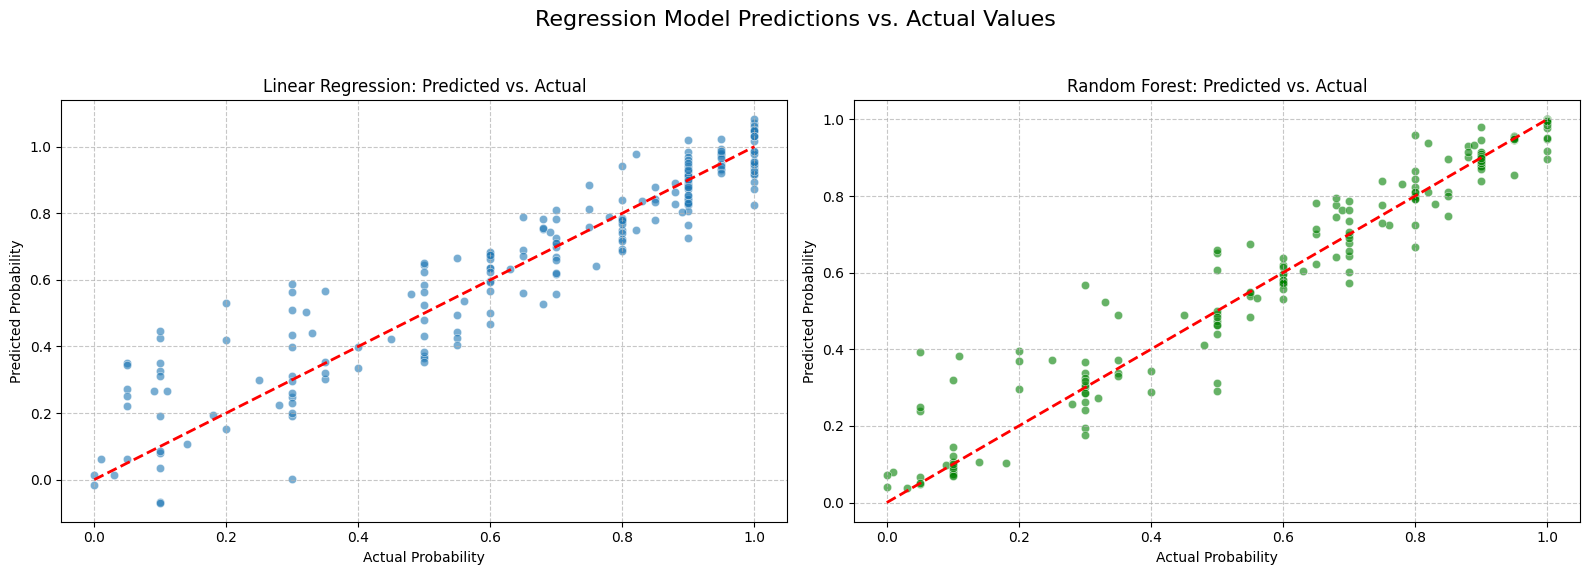

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Regression Model Predictions vs. Actual Values', fontsize=16)

# Plotting for Linear Regression
sns.scatterplot(x=y_test_final, y=y_pred_linear, ax=axes[0], alpha=0.6)
axes[0].plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression: Predicted vs. Actual')
axes[0].set_xlabel('Actual Probability')
axes[0].set_ylabel('Predicted Probability')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plotting for Random Forest Regressor
sns.scatterplot(x=y_test_final, y=y_pred_rf, ax=axes[1], alpha=0.6, color='green')
axes[1].plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'r--', lw=2)
axes[1].set_title('Random Forest: Predicted vs. Actual')
axes[1].set_xlabel('Actual Probability')
axes[1].set_ylabel('Predicted Probability')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

We can see that the blue dots (linear regression model) are somewhat scattered around the red dashed line (regression line), especially at higher actual probability values which suggests that the Linear Regression model has a noticeable amount of error. The green dots are much more tightly clustered around the red dashed line compared to the Linear Regression plot. This indicates that the Random Forest model's predictions are generally much closer to the actual probabilities as supported by the numerical performance metrics shown below.

Let us now compare the metrics side-by-side for both regression models:

In [30]:
import pandas as pd

# Create a dictionary to hold the metrics
metrics_data = {
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R2)'],
    'Linear Regression': [mae_linear, mse_linear, rmse_linear, r2_linear],
    'Random Forest Regressor': [mae_rf, mse_rf, rmse_rf, r2_rf]
}

# Create a DataFrame for better display
metrics_df = pd.DataFrame(metrics_data)

print("\n--- Model Performance Comparison ---")
display(metrics_df.round(4))

print("\n--- Explanation ---")
print("Based on these metrics, the Random Forest Regressor clearly outperforms the Linear Regression model. It has significantly lower MAE, MSE, and RMSE values, indicating that its predictions are much closer to the actual recommendation probabilities. Additionally, its R-squared value is higher (0.9436 vs 0.8813), meaning it explains a greater proportion of the variance in the target variable. In simpler terms, the Random Forest model is more accurate and captures the underlying patterns in the data better for predicting product recommendation probability.")


--- Model Performance Comparison ---


,Metric,Linear Regression,Random Forest Regressor
0,Mean Absolute Error (MAE),0.0767,0.0434
1,Mean Squared Error (MSE),0.0110,0.0052
2,Root Mean Squared Error (RMSE),0.1048,0.0722
3,R-squared (R2),0.8813,0.9436



--- Explanation ---
Based on these metrics, the Random Forest Regressor clearly outperforms the Linear Regression model. It has significantly lower MAE, MSE, and RMSE values, indicating that its predictions are much closer to the actual recommendation probabilities. Additionally, its R-squared value is higher (0.9436 vs 0.8813), meaning it explains a greater proportion of the variance in the target variable. In simpler terms, the Random Forest model is more accurate and captures the underlying patterns in the data better for predicting product recommendation probability.


Based on these metrics, the Random Forest Regressor clearly outperforms the Linear Regression model. It has significantly lower MAE, MSE, and RMSE values, indicating that its predictions are much closer to the actual recommendation probabilities. Additionally, its R-squared value is higher (0.9436 vs 0.8813), meaning it explains a greater proportion of the variance in the target variable (probability to be recommended). In simpler terms, the Random Forest model is more accurate and captures the underlying patterns in the data better for predicting product recommendation probability.

### Bias & Fairness Analysis

We shall discuss the potential biases of our experiment.

1. **Transparency is Key**: The interpretability of Linear
Regression coefficients helps pinpoint which features have positive or negative influence, making it easier to spot potential biases. For example for *brands* as more people tend to repurchase their trusted brands rather than testing out different ones.

2. **Reliance on Quality Metrics**: Both models heavily weigh customer reviews and ratings, which is ethically sound, promoting recommendations based on product merit. However, we should note that these customer reviews are sometimes subjective or at worst case scenario, they are fake or boosted reviews.

3. **Watch for Sensitive Attributes and Proxies**: Features like *Gender*, specific *Brands* or *Geographical locations* need extra scrutiny. We must audit how our model performs for different demographic groups to ensure fairness, not just overall accuracy, as these factors affect purchasing decisions of individuals.

### Conclusion: Enhancing Product Recommendation through Machine Learning

This experiment aimed to develop a content-based recommendation model for an e-commerce platform by predicting the probability of a product being recommended to a customer. We successfully navigated through the machine learning lifecycle, from data preprocessing and feature selection to model training, evaluation, and comparison.

**Key Findings:**

1.  **Effective Data Preprocessing and Feature Selection:** Through `OneHotEncoder`, `StandardScaler`, and `LassoCV`, we transformed raw data into a clean, normalized, and optimized feature set, reducing the original 66 features to 44 most impactful ones. This step was crucial for improving model efficiency and interpretability.

2.  **Superior Performance of Random Forest Regressor:** Our comparison between Linear Regression and Random Forest Regressor clearly demonstrated the latter's superior predictive capability. The Random Forest model achieved significantly lower error metrics (MAE, MSE, RMSE) and a substantially higher R-squared value (0.9436 vs. 0.8813), indicating a much better fit to the data and more accurate predictions of recommendation probability. This was visually confirmed by the tighter clustering of predicted vs. actual values around the ideal line in the Random Forest plot.

3.  **Feature Importance Insights:**
    *   **Customer Review Sentiment** and **Product Rating** consistently emerged as the most critical features across both models, underscoring the importance of product quality and user satisfaction in driving recommendations.
    *   **Brand of the Product** also played a significant role, though with varying impacts, suggesting that brand perception heavily influences recommendation likelihood. This insight could guide inventory management and marketing strategies.
    *   Less impactful features, particularly some specific brand categories, suggest that their individual presence might not strongly dictate recommendation probability.

4.  **Ethical Considerations:** We acknowledged the importance of bias and fairness, emphasizing the need for transparency in model coefficients (as provided by Linear Regression) and careful auditing of sensitive attributes like gender or geographical location. While customer review-based metrics are generally ethically sound, continuous vigilance is required against potential biases or manipulated data.

**In essence, the Random Forest Regressor provides a robust and accurate model for predicting product recommendation probability based on product content and customer interactions. The insights gained from feature importance can directly inform business decisions, allowing the e-commerce platform to enhance personalization, optimize product discovery, and ultimately improve user engagement and satisfaction.**